<a href="https://colab.research.google.com/github/QuangDuy1512/ecommerce-behavior-analysis/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Đọc dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/personal_projects/2019-Dec.csv"

df = pd.read_csv(
    file_path,
    nrows=150000
)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,556695836,ca5eefc5-11f9-450c-91ed-380285a0bc80
1,2019-12-01 00:00:00 UTC,view,22700068,2232732091643068746,NaN,force,102.96,577702456,de33debe-c7bf-44e8-8a12-3bf8421f842a
2,2019-12-01 00:00:01 UTC,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,539453785,5ee185a7-0689-4a33-923d-ba0130929a76
3,2019-12-01 00:00:02 UTC,purchase,26400248,2053013553056579841,computers.peripherals.printer,NaN,132.31,535135317,61792a26-672f-4e61-9832-7b63bb1714db
4,2019-12-01 00:00:02 UTC,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,517987650,906c6ca8-ff5c-419a-bde9-967ba8e2233e


In [ ]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 150,000
Columns : 9


# Tổng quan dữ liệu

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     150000 non-null  object 
 1   event_type     150000 non-null  object 
 2   product_id     150000 non-null  int64  
 3   category_id    150000 non-null  int64  
 4   category_code  132203 non-null  object 
 5   brand          131046 non-null  object 
 6   price          150000 non-null  float64
 7   user_id        150000 non-null  int64  
 8   user_session   150000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 10.3+ MB


In [ ]:
df.columns.tolist()

['event_time',
 'event_type',
 'product_id',
 'category_id',
 'category_code',
 'brand',
 'price',
 'user_id',
 'user_session']

In [ ]:
# Bảng dữ liệu tóm tắt
summary = pd.DataFrame({
    "Unique Values":
    df.nunique(),

    "Data Type":
    df.dtypes

})
summary

,Unique Values,Data Type
event_time,15857,object
event_type,3,object
product_id,27285,int64
category_id,929,int64
category_code,134,object
brand,2035,object
price,9229,float64
user_id,26395,int64
user_session,33222,object


# Mô tả bộ dữ liệu

Bộ dữ liệu ghi nhận các hành vi tương tác của người dùng trên một nền tảng thương mại điện tử. Mỗi dòng dữ liệu tương ứng với một sự kiện mà người dùng thực hiện đối với một sản phẩm cụ thể.

## Các thuộc tính của bộ dữ liệu

| Thuộc tính | Mô tả |
|------------|--------|
| **event_time** | Thời điểm sự kiện xảy ra, được lưu theo chuẩn giờ UTC. |
| **event_type** | Loại sự kiện mà người dùng thực hiện đối với sản phẩm. |
| **product_id** | Mã định danh duy nhất của sản phẩm. |
| **category_id** | Mã định danh của danh mục sản phẩm. |
| **category_code** | Tên hoặc mã phân loại của danh mục sản phẩm. Thuộc tính này có thể xuất hiện đối với các danh mục có ý nghĩa cụ thể và có thể bị thiếu ở một số nhóm sản phẩm. |
| **brand** | Tên thương hiệu của sản phẩm, được lưu dưới dạng chữ thường. Một số bản ghi có thể không có thông tin thương hiệu. |
| **price** | Giá của sản phẩm tại thời điểm ghi nhận sự kiện, được lưu dưới dạng số thực. |
| **user_id** | Mã định danh duy nhất của người dùng. |
| **user_session** | Mã định danh phiên truy cập của người dùng. Mỗi phiên truy cập sẽ có một mã riêng và mã này thay đổi khi người dùng quay lại hệ thống sau một khoảng thời gian không hoạt động. |

## Các loại sự kiện

Bộ dữ liệu bao gồm bốn loại sự kiện chính:

1. **view**: Người dùng xem thông tin của một sản phẩm.
2. **cart**: Người dùng thêm sản phẩm vào giỏ hàng.
3. **remove_from_cart**: Người dùng xóa sản phẩm khỏi giỏ hàng.
4. **purchase**: Người dùng hoàn tất việc mua sản phẩm.

## Ý nghĩa của bộ dữ liệu

Bộ dữ liệu cung cấp thông tin về toàn bộ hành trình mua sắm của khách hàng trên nền tảng thương mại điện tử, từ giai đoạn xem sản phẩm, thêm vào giỏ hàng đến khi hoàn tất giao dịch. Dữ liệu này có thể được sử dụng để phân tích hành vi người dùng, đánh giá hiệu quả kinh doanh, xây dựng hệ thống gợi ý sản phẩm và phát triển các mô hình dự đoán khả năng mua hàng của khách hàng.

# Đánh giá giá trị thiếu

In [ ]:
missing_df = pd.DataFrame({
    "Missing Count":df.isnull().sum(),
    "Missing Percent":round(df.isnull().mean()*100,2)
})

missing_df.sort_values("Missing Percent",ascending=False)

,Missing Count,Missing Percent
brand,18954,12.64
category_code,17797,11.86
event_time,0,0.00
product_id,0,0.00
event_type,0,0.00
category_id,0,0.00
price,0,0.00
user_id,0,0.00
user_session,0,0.00


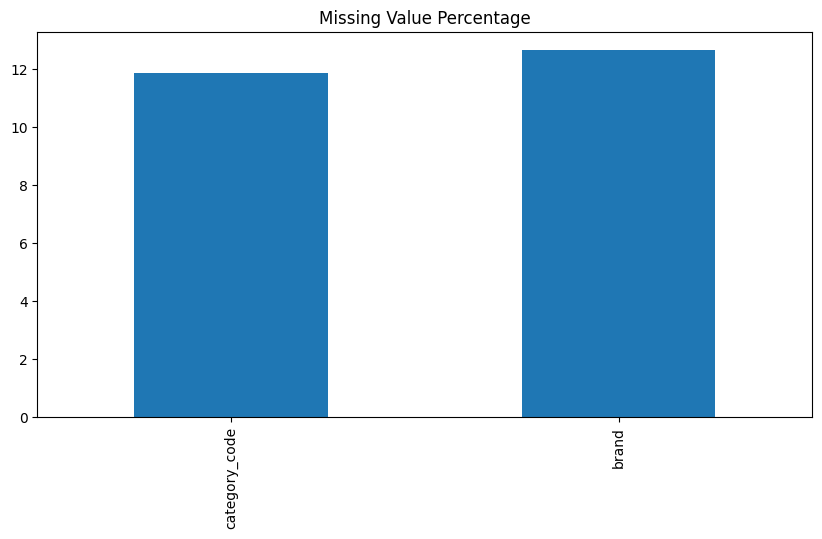

In [ ]:
# Trực quan hóa giá trị thiếu
plt.figure(figsize=(10,5))

missing_df[missing_df["Missing Count"] > 0]["Missing Percent"].plot(kind="bar")

plt.title( "Missing Value Percentage")

plt.show()

# Đánh giá trùng lặp

In [ ]:
duplicate_rows = (df.duplicated().sum())

print(
    f"Duplicate Rows: "
    f"{duplicate_rows:,}"
)

Duplicate Rows: 109


In [ ]:
duplicate_events = (
    df.duplicated(
        subset=[
            "event_time",
            "user_id",
            "product_id",
            "event_type"
        ]
    )
    .sum()
)

print(
    f"Business Duplicates: "
    f"{duplicate_events:,}"
)

Business Duplicates: 123


# Đánh giá kiểu dữ liệu

In [ ]:
# Các cột có kiểu giá trị số
numeric_cols = (df.select_dtypes(include=np.number).columns)
numeric_cols

Index(['product_id', 'category_id', 'price', 'user_id'], dtype='object')

In [ ]:
# Các cột có kiểu giá trị phân loại
categorical_cols = (df.select_dtypes(include="object").columns)
categorical_cols

Index(['event_time', 'event_type', 'category_code', 'brand', 'user_session'], dtype='object')

# Đánh giá chuỗi thời gian ban đầu (time-series)

In [ ]:
df["event_time"] = pd.to_datetime(
    df["event_time"].astype(str),
    utc=True,
    errors="coerce"
)
df["event_time"]

,event_time
0,2019-12-01 00:00:00+00:00
1,2019-12-01 00:00:00+00:00
2,2019-12-01 00:00:01+00:00
3,2019-12-01 00:00:02+00:00
4,2019-12-01 00:00:02+00:00
...,...
149995,2019-12-01 04:27:57+00:00
149996,2019-12-01 04:27:57+00:00
149997,2019-12-01 04:27:57+00:00
149998,2019-12-01 04:27:57+00:00


In [ ]:
print(
    "Start Date:",
    df["event_time"].min()
)

print(
    "End Date:",
    df["event_time"].max()
)

Start Date: 2019-12-01 00:00:00+00:00
End Date: 2019-12-01 04:27:57+00:00


# Đánh giá hành vi người dùng

In [ ]:
df["event_type"].value_counts()

,count
event_type,
view,142339
cart,5770
purchase,1891


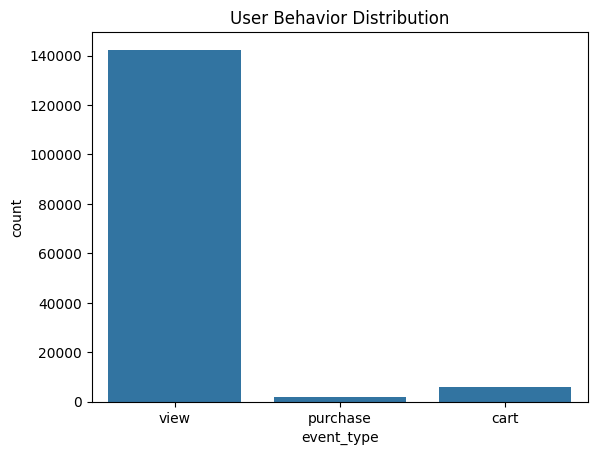

In [ ]:
sns.countplot(data=df,x="event_type")
plt.title("User Behavior Distribution")
plt.show()

# Đánh giá sản phẩm

In [ ]:
print(
    f"Unique Products: "
    f"{df['product_id'].nunique():,}"
)

Unique Products: 27,285


In [ ]:
print(
    f"Unique Users: "
    f"{df['user_id'].nunique():,}"
)

Unique Users: 26,395


In [ ]:
print(
    f"Unique Brands: "
    f"{df['brand'].nunique():,}"
)

Unique Brands: 2,035


# Kết luận
Sau khi tìm hiểu kỹ về dữ liệu ban đầu (Data Understanding) đối với tập dữ liệu mẫu 150.000 dòng trích xuất từ tập dữ liệu gốc Thương mại điện tử tháng 12/2019, ta có kết luận:

**1. Quy mô và Cấu trúc bộ dữ liệu (Data Schema & Scale)**

- Tổng số bản ghi ban đầu: Ghi nhận chính xác 150,000 dòng dữ liệu tương ứng với 9 thuộc tính hình thành nên cấu trúc hành trình khách hàng.

- Định danh đối tượng: Hệ thống bao gồm 27,285 sản phẩm duy nhất (product_id) đến từ 2,035 thương hiệu (brand), được tương tác bởi 26,395 người dùng (user_id) thông qua 33,222 phiên truy cập (user_session).

**2. Chất lượng dữ liệu & Điểm cần lưu ý khi Tiền xử lý (Data Quality & Preprocessing Focus)**

- Giá trị thiếu (Missing Values): Tập dữ liệu ghi nhận tỷ lệ thiếu khá cao ở 2 thuộc tính quan trọng là Thương hiệu (brand với thiếu 12,64%) và Mã phân loại danh mục (category_code thiếu 11.86%). Các giá trị còn lại đầy đủ không thiếu.

- Giá trị trùng lặp (Data Duplication): Hệ thống phát hiện 109 dòng trùng lặp tuyệt đối (trùng hoàn toàn 9 cột) và 123 dòng trùng lặp nghiệp vụ (Business Duplicates) trên các thuộc tính định danh chính (event_time, user_id, product_id, event_type). Tỷ lệ này rất nhỏ nên có thể dễ dàng làm sạch hoàn toàn bằng cách loại bỏ giữ lại bản ghi đầu tiên (drop_duplicates).

**3. Phân tích Chuỗi thời gian (Time-Series Insights)**

- Vì chỉ lấy tập mẫu 150,000 dòng để hiểu nên các dòng này chỉ đang quét qua một khoảng thời gian rất hẹp: Từ 00:00:00 ngày 01/12/2019 đến 04:27:57 ngày 01/12/2019 (khoảng gần 4.5 tiếng đồng hồ đầu tiên của ngày).

- Điều này phản ánh tần suất sự kiện của sàn TMĐT diễn ra với mật độ cực kỳ khổng lồ (vài chục nghìn sự kiện/giờ).

**4. Đặc trưng Hành vi Người dùng (User Behavior)**

- Xem sản phẩm (view): Chiếm đại đa số tuyệt đối với 142,339 lượt, chứng tỏ người dùng dành phần lớn thời gian để duyệt và khám phá sản phẩm.

- Thêm vào giỏ (cart): Giảm mạnh xuống còn 5,770 lượt.

- Hoàn tất đơn hàng (purchase): Đạt 1,891 lượt mua thành công.
  
- Tỷ lệ chuyển đổi tổng thể từ Xem sang Mua hàng (CR) đạt mức sơ bộ khoảng 1.33% ($1,891 / 142,339$)